# Visualization of Phantom

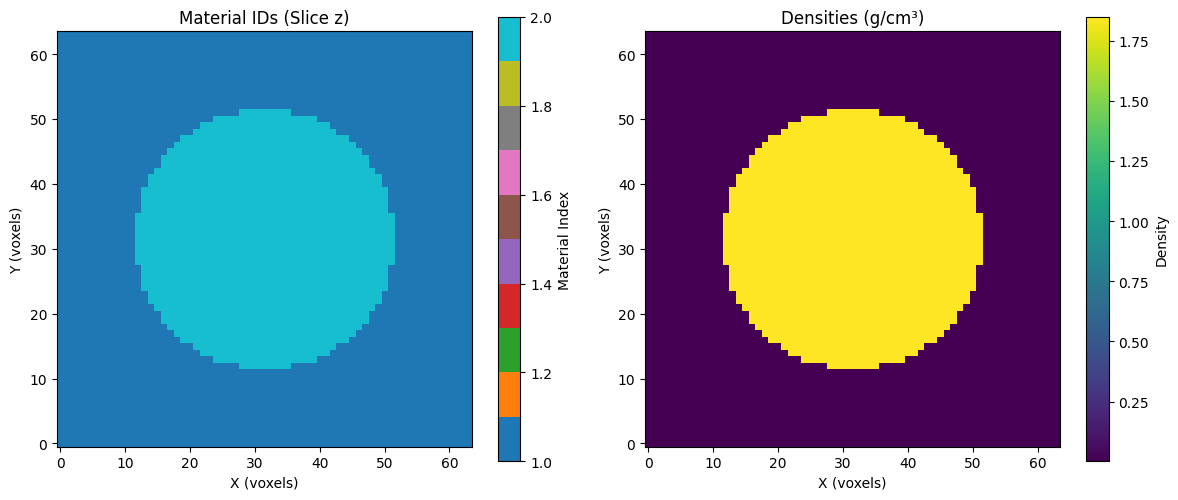

In [4]:
import matplotlib.pyplot as plt
from petsim.phantom import Phantom

def plot_phantom_slice(phantom: Phantom, axis: str = 'z', slice_idx: int | None = None):
    """
    Plots a 2D cross-section of the phantom's material IDs and densities.
    """
    # 1. Determine which axis to slice along
    # material_ids.shape is (nx, ny, nz)
    if axis == 'x':
        data_ids = phantom.material_ids[slice_idx if slice_idx is not None else phantom.shape[0]//2, :, :]
        data_dens = phantom.densities[slice_idx if slice_idx is not None else phantom.shape[0]//2, :, :]
        xlabel, ylabel = "Y (voxels)", "Z (voxels)"
    elif axis == 'y':
        data_ids = phantom.material_ids[:, slice_idx if slice_idx is not None else phantom.shape[1]//2, :]
        data_dens = phantom.densities[:, slice_idx if slice_idx is not None else phantom.shape[1]//2, :]
        xlabel, ylabel = "X (voxels)", "Z (voxels)"
    else:  # 'z' axis
        data_ids = phantom.material_ids[:, :, slice_idx if slice_idx is not None else phantom.shape[2]//2]
        data_dens = phantom.densities[:, :, slice_idx if slice_idx is not None else phantom.shape[2]//2]
        xlabel, ylabel = "X (voxels)", "Y (voxels)"

    # 2. Setup the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot Material IDs (Categorical)
    im1 = ax1.imshow(data_ids.T, origin='lower', cmap='tab10')
    ax1.set_title(f"Material IDs (Slice {axis})")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    fig.colorbar(im1, ax=ax1, label="Material Index")

    # Plot Densities (Continuous)
    im2 = ax2.imshow(data_dens.T, origin='lower', cmap='viridis')
    ax2.set_title(f"Densities (g/cm³)")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel)
    fig.colorbar(im2, ax=ax2, label="Density")

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
ph = Phantom.sphere(shape=(64, 64, 64), voxel_size=(0.1, 0.1, 0.1), radius_cm=2.0, inner_material="bone", inner_density=1.85)
plot_phantom_slice(ph, axis='z')

# Pipeline test

## The core loop
Every simulation starts the same way regardless of backend:

In [2]:
from petsim.phantom import Phantom
from petsim.source import Source
from petsim.scanner import Scanner
from petsim.run import Run

# 1. Define the object being scanned
phantom = Phantom.cube(
    shape=(9, 9, 9),
    voxel_size=(1.0, 1.0, 1.0),       # cm
    inner_material="water", inner_density=1.0,
    outer_material="air", outer_density=0.0012,
    inner_size_vox=5,
)

# 2. Define where the radiotracer is
source = Source.with_total_activity(
    phantom,
    material="water",
    total_activity_Bq=1e6,
    isotope="F18",
)

# 3. Pick a scanner geometry
scanner = Scanner.from_preset("mcgpu_sample")

# 4. Bundle everything into a Run
run = Run(phantom=phantom, source=source, scanner=scanner, seed=42)

# 5. Save to runs for further reuse
PATH = "./runs/exp1"
run.save(PATH)

The Run is the single object both backends accept. It's also saveable — run.save("/tmp/my_run") writes a directory with run.yaml, phantom.npz, source.npz, scanner.yaml that you can reload later with Run.load(...).

## Running with MCGPU-PET

In [4]:
from petsim.backends import MCGPUBackend

backend = MCGPUBackend(
    executable="./MCGPU-PET/MCGPU-PET.x",
    materials_dir="./MCGPU-PET/sample_simulation/materials",
)

sinogram, result = backend.run_full(run, workdir="/tmp/mcgpu_run_01")

RuntimeError: MCGPU-PET exited with code 254; see /tmp/mcgpu_run_01/MCGPU-PET.out and /tmp/mcgpu_run_01/MCGPU-PET.err

That single call does three things under the hood. First, it writes phantom.vox and MCGPU-PET.in into the workdir and symlinks the materials directory. Second, it invokes ./MCGPU-PET.x MCGPU-PET.in as a subprocess, capturing stdout to MCGPU-PET.out. Third, it reads sinogram_Trues.raw (and sinogram_Scatter.raw if present) back into a Sinogram object.

If you want to inspect or modify the generated files before running, use the three-step API instead:

In [ ]:
workdir = backend.stage_inputs(run, "/tmp/mcgpu_run_01")
# Now look at workdir/phantom.vox, workdir/MCGPU-PET.in
# Edit them if needed, then:
result = backend.invoke(workdir, timeout_s=300)
sinogram = backend.parse_sinogram(run, result)

The result object gives you result.wall_time_s, result.returncode, and result.stdout_path for debugging. Counts always come from summing the binary arrays, never from log parsing.

## Running with GATE

In [ ]:
from petsim.backends import GATEBackend

backend = GATEBackend()
sinogram, result = backend.run_full(run, workdir="/tmp/gate_run_01")

Same interface, different backend. Internally GATE doesn't need input files on disk — it builds an opengate.Simulation object in memory, exports the phantom and source as .mhd/.raw image pairs, and runs in-process. If you want to modify the GATE simulation before running (add a custom physics process, change the digitizer, etc.):

In [ ]:
sim = backend.build(run, "/tmp/gate_run_01")
# sim is a regular opengate Simulation — tweak whatever you want
sim.physics_manager.enable_decay = True
sim.run()
# Then parse manually:
from petsim.backends.gate import GATERunResult
result = GATERunResult(workdir=Path("/tmp/gate_run_01"), wall_time_s=...,
                       sinogram_output_path=Path("/tmp/gate_run_01/sinogram.mhd"))
sinogram = backend.parse_sinogram(run, result)

One caveat: the GATE backend's ring repeater call may need adjustment for your installed opengate version. The detector geometry it builds is a simplified single-ring cylinder — good enough for validation against MCGPU-PET on simple phantoms, but not a production scanner model.

## Working with the Sinogram

Both backends return the same Sinogram object:

In [ ]:
print(sinogram.total_trues)        # sum of all true coincidence bins
print(sinogram.total_scatter)      # sum of scatter bins (None if not tallied)
print(sinogram.scatter_fraction)   # scatter / (trues + scatter)
print(sinogram.trues.shape)        # (n_z_slices, n_angular_bins, n_radial_bins)

# Save for later
sinogram.save("/tmp/mcgpu_run_01/sinogram.npz")

## Customizing the MCGPUConfig


The MCGPUConfig dataclass holds everything that's simulator-specific rather than scanner-specific:

In [ ]:
from petsim.backends import MCGPUConfig

config = MCGPUConfig(
    gpu_number=0,              # which GPU to use
    threads_per_block=32,      # CUDA threads
    report_output_mode=2,      # 2 = sinogram only (skip PSF, faster)
    psf_size=50_000_000,       # smaller PSF buffer
    tally_voxel_dose=True,     # enable per-voxel dose map
)
sinogram, result = backend.run_full(run, "/tmp/run", config=config)

## Building more complex phantoms
Phantom has several factory methods: uniform, cube, cylinder, sphere. For anything more complex, use from_numpy:

In [ ]:
import numpy as np

mat_ids = np.ones((64, 64, 64), dtype=np.int32)       # all material 1
mat_ids[20:44, 20:44, 20:44] = 2                       # inner cube = material 2
densities = np.full((64, 64, 64), 0.0012, dtype=np.float64)
densities[20:44, 20:44, 20:44] = 1.0

phantom = Phantom.from_numpy(
    material_ids=mat_ids,
    densities=densities,
    voxel_size=(0.2, 0.2, 0.2),  # 2mm voxels in cm
    material_names=("air", "water"),
)

The material names tuple is ordered by ID: index 0 → ID 1, index 1 → ID 2. The MaterialRegistry maps these names to the actual .mcgpu.gz cross-section files for MCGPU-PET, or to Geant4 material names (G4_WATER, etc.) for GATE.
The short version
Define your scene once with Phantom + Source + Scanner + Run. Pass the Run to whichever backend you want. Get a Sinogram back. The backends handle all the format conversion, unit conversion (cm↔mm, keV↔eV), file I/O, and subprocess management internally.